## **Read data and Imports**

In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=3000)]
    )

In [6]:
import pandas as pd
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skrebate import ReliefF
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import os
import random
import cv2
import sklearn
from sklearn.feature_selection import (
    mutual_info_regression,  # Information Gain
    chi2,                    # Chi-square Test
    f_classif,               # ANOVA (F-test)
    SelectKBest,             # Select top k features
    VarianceThreshold        # Variance Threshold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## **Path Setup**

Total images: 13015


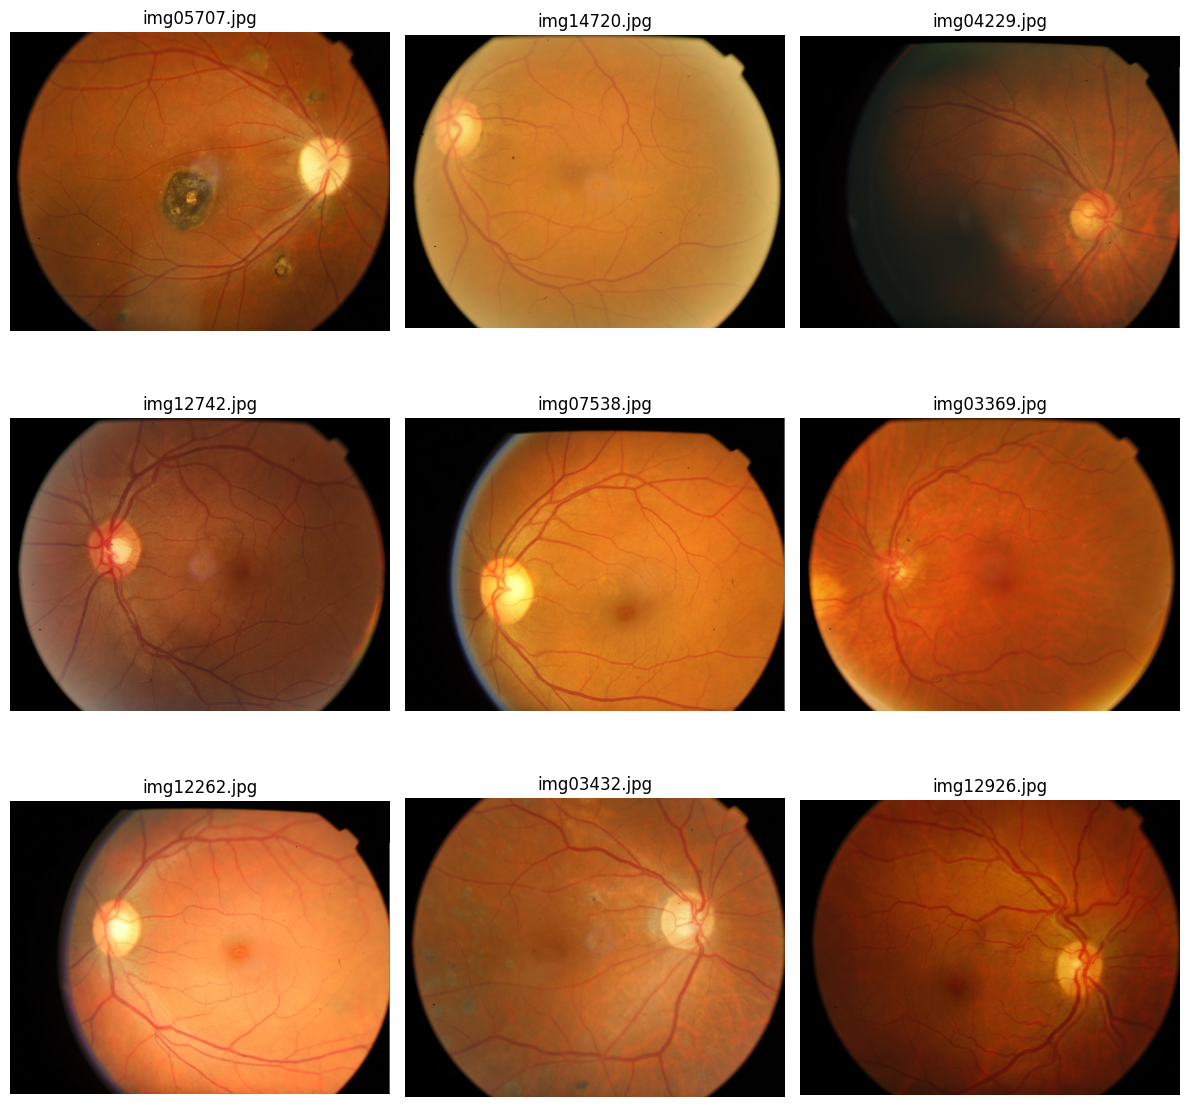

In [7]:
folder = "../../Data/dataset_split/train/images"
image_paths = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Total images:", len(image_paths))

sample_paths = random.sample(image_paths, 9)

plt.figure(figsize=(12, 12))

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(os.path.basename(path))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
sizes = []

for path in sample_paths:
    img = cv2.imread(path)
    h, w = img.shape[:2]
    sizes.append((h, w))
    print(os.path.basename(path), "->", (h, w))

img05707.jpg -> (1880, 2390)
img14720.jpg -> (2304, 2984)
img04229.jpg -> (2056, 2672)
img12742.jpg -> (2304, 2984)
img07538.jpg -> (2056, 2672)
img03369.jpg -> (2304, 2984)
img12262.jpg -> (2056, 2672)
img03432.jpg -> (1880, 2390)
img12926.jpg -> (1880, 2420)


## **Preprocessing**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input


# =========================
# 1) CROP
# =========================
def crop_black_borders(img_rgb, threshold=20):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold

    coords = np.argwhere(mask)
    if coords.size == 0:
        return img_rgb

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return img_rgb[y0:y1, x0:x1]

d
# =========================
# 2) FOV MASK
# =========================
def create_fov_mask(img_rgb, threshold=20):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    mask = (gray > threshold).astype(np.uint8) * 255

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask


# =========================
# 3) OPTION 3: REPLACE BLACK CORNERS WITH BLENDED BACKGROUND
# =========================
def replace_black_corners_blended(img_rgb, mask):
    blurred = cv2.GaussianBlur(img_rgb, (51, 51), 0)

    mask_float = mask.astype(np.float32) / 255.0
    mask_float = np.expand_dims(mask_float, axis=-1)

    result = img_rgb * mask_float + blurred * (1.0 - mask_float)
    result = np.clip(result, 0, 255).astype(np.uint8)

    return result


# =========================
# 4) CLAHE ON RGB USING LAB
# =========================
def apply_clahe_lab_rgb(img_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge([l_clahe, a, b])

    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return img_clahe


# =========================
# 5) FULL PIPELINE D - RGB ONLY
# =========================
def preprocess_pipeline_d(
    path,
    target_size=(224, 224),
    threshold=20,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    use_resnet_preprocess=True
):
    img_bgr = cv2.imread(path)

    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    print("Original image shape:", original.shape)

    # 1) crop
    cropped = crop_black_borders(original, threshold=threshold)
    print("After crop shape:", cropped.shape)

    # 2) create FOV mask once
    fov_mask = create_fov_mask(cropped, threshold=threshold)
    print("FOV mask shape:", fov_mask.shape)

    # 3) replace black corners using option 3
    blended_background = replace_black_corners_blended(cropped, fov_mask)
    print("After background replacement shape:", blended_background.shape)

    # 4) CLAHE on RGB/LAB luminance
    clahe_rgb = apply_clahe_lab_rgb(
        blended_background,
        clip_limit=clip_limit,
        tile_grid_size=tile_grid_size
    )
    print("After CLAHE RGB shape:", clahe_rgb.shape)

    # 5) resize
    resized = cv2.resize(clahe_rgb, target_size)
    print("After resize shape:", resized.shape)

    # 6) model preprocessing
    processed = resized.astype(np.float32)

    if use_resnet_preprocess:
        processed = preprocess_input(processed)
        print("After ResNet50 preprocess_input shape:", processed.shape)
    else:
        processed = processed / 255.0
        print("After 0-1 normalization shape:", processed.shape)

    return {
        "original": original,
        "cropped": cropped,
        "fov_mask": fov_mask,
        "blended_background": blended_background,
        "clahe_rgb": clahe_rgb,
        "resized": resized,
        "processed": processed
    }


# =========================
# 6) VISUALIZATION
# =========================
def visualize_pipeline_d(path):
    out = preprocess_pipeline_d(path)

    titles = [
        "original",
        "cropped",
        "fov_mask",
        "blended_background",
        "clahe_rgb",
        "resized",
        "processed_preview"
    ]

    plt.figure(figsize=(18, 8))

    for i, key in enumerate(titles):
        plt.subplot(2, 4, i + 1)

        if key == "processed_preview":
            img = out["resized"]   # preview before preprocess_input
        else:
            img = out[key]

        if key == "fov_mask":
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)

        plt.title(key)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return out

2026-05-09 04:12:24.816924: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-09 04:12:24.817145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 04:12:24.873296: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-09 04:12:24.983611: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 04:12:26.412697: W tensorflow/compiler/tf2

Original image shape: (1880, 2390, 3)
After crop shape: (1880, 2353, 3)
FOV mask shape: (1880, 2353)
After blended background shape: (1880, 2353, 3)
After CLAHE RGB shape: (1880, 2353, 3)
After resize shape: (224, 224, 3)
After ResNet50 preprocess_input shape: (224, 224, 3)
Processed min: -115.779
Processed max: 131.32


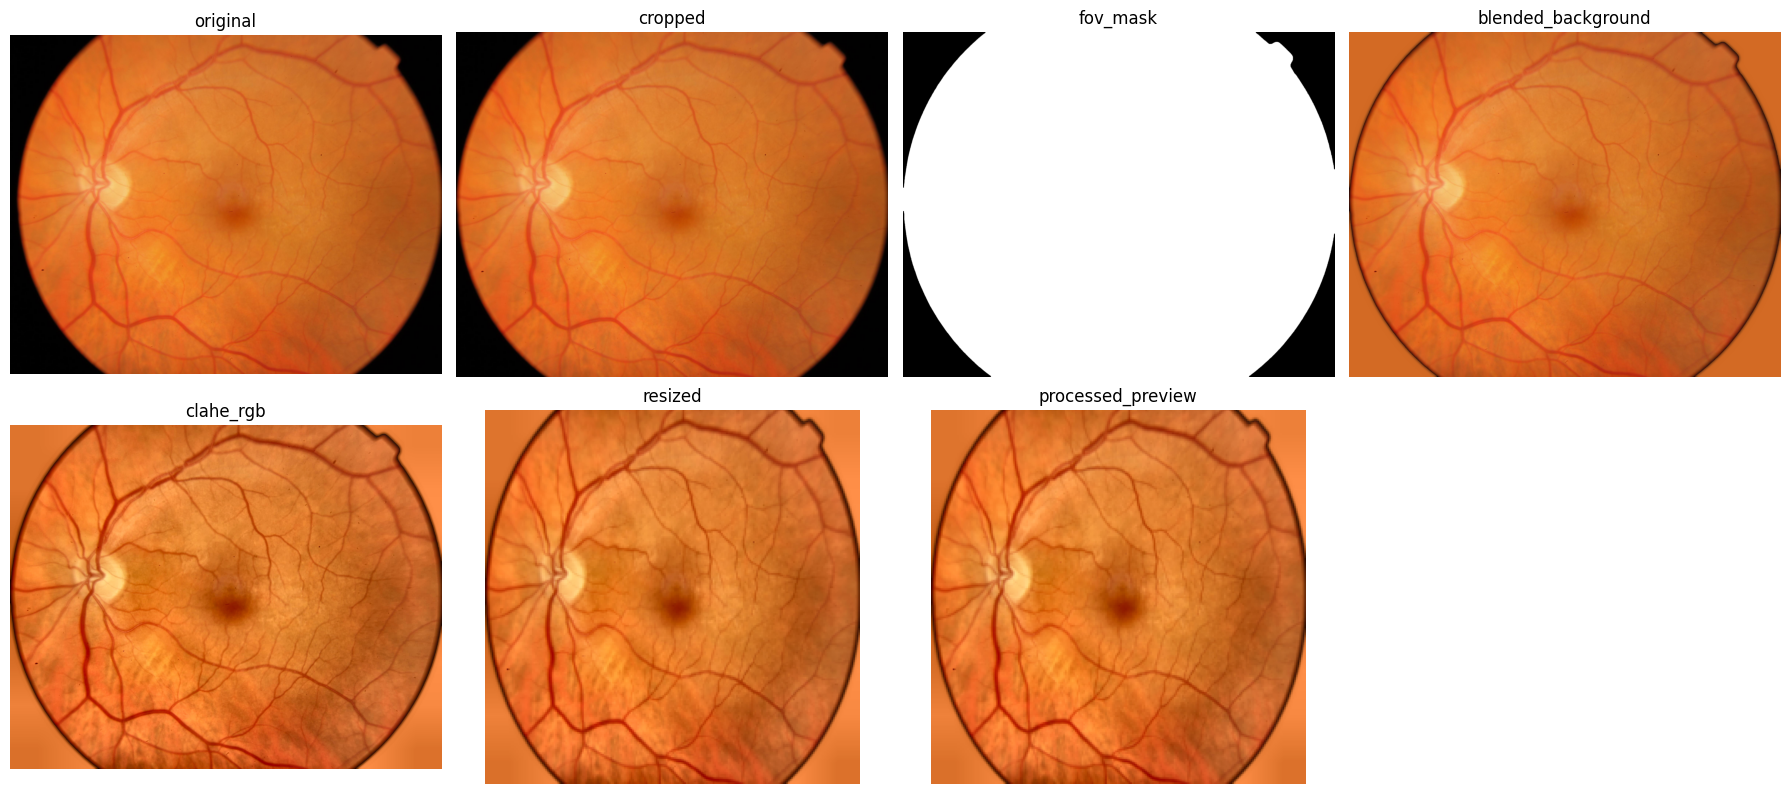

(224, 224, 3)


In [6]:
path = image_paths[5005]
out = visualize_pipeline_d(path)

model_input = out["processed"]
print(model_input.shape)

In [7]:
PROCESSED_TRAIN_DIR = "../../Data/dataset_split/train/images_processed"
PROCESSED_VAL_DIR   = "../../Data/dataset_split/val/images_processed"
PROCESSED_TEST_DIR  = "../../Data/dataset_split/test/images_processed"

In [8]:
import os
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = (224, 224)


# =========================
# 1) CROP BLACK BORDERS
# =========================
def crop_black_borders(img_rgb, threshold=20):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold

    coords = np.argwhere(mask)

    if coords.size == 0:
        return img_rgb

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return img_rgb[y0:y1, x0:x1]


# =========================
# 2) CREATE CLEAN FOV MASK
# =========================
def create_fov_mask(img_rgb, threshold=20):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    mask = (gray > threshold).astype(np.uint8) * 255

    kernel = np.ones((9, 9), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return mask

    largest = max(contours, key=cv2.contourArea)

    clean_mask = np.zeros_like(mask)

    cv2.drawContours(
        clean_mask,
        [largest],
        -1,
        255,
        thickness=-1
    )

    return clean_mask


# =========================
# 3) REPLACE BLACK CORNERS
# Mean retinal color + soft boundary blending
# =========================
def replace_black_corners_blended(img_rgb, mask, blur_kernel=51):
    """
    Replaces outside-retina pixels with mean retinal color,
    then softly blends the transition boundary.
    """

    if blur_kernel % 2 == 0:
        blur_kernel += 1

    # retina = 1, background = 0
    mask_bin = (mask > 0).astype(np.uint8)

    retina_pixels = img_rgb[mask_bin == 1]

    if len(retina_pixels) == 0:
        return img_rgb

    # mean retinal RGB color
    mean_color = retina_pixels.mean(axis=0).astype(np.uint8)

    # fill outside-retina background with mean retinal color
    filled = img_rgb.copy()
    filled[mask_bin == 0] = mean_color

    # soft mask for smooth boundary
    soft_mask = cv2.GaussianBlur(
        mask_bin.astype(np.float32),
        (blur_kernel, blur_kernel),
        0
    )

    soft_mask = np.expand_dims(soft_mask, axis=-1)

    # blend retina from original + background from filled
    result = (
        img_rgb.astype(np.float32) * soft_mask
        + filled.astype(np.float32) * (1.0 - soft_mask)
    )

    result = np.clip(result, 0, 255).astype(np.uint8)

    return result


# =========================
# 4) CLAHE ON RGB USING LAB
# =========================
def apply_clahe_lab_rgb(
    img_rgb,
    clip_limit=2.0,
    tile_grid_size=(8, 8)
):
    """
    Apply CLAHE to luminance only.
    Keeps RGB color information.
    """

    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge([l_clahe, a, b])

    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return img_clahe


# =========================
# 5) PREPROCESS AND SAVE IMAGE
# Saves uint8 RGB-preprocessed image as PNG/JPG
# No ResNet preprocess_input here because saved images should remain visual.
# =========================
def preprocess_and_save_image(
    input_path,
    output_path,
    target_size=(224, 224),
    crop_threshold=20,
    mask_threshold=20,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    blur_kernel=51
):
    img_bgr = cv2.imread(input_path)

    if img_bgr is None:
        return False

    # BGR -> RGB
    original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 1) crop black rectangular borders
    cropped = crop_black_borders(
        original,
        threshold=crop_threshold
    )

    # 2) create FOV mask once
    fov_mask = create_fov_mask(
        cropped,
        threshold=mask_threshold
    )

    # 3) replace outside-retina background
    background_replaced = replace_black_corners_blended(
        cropped,
        fov_mask,
        blur_kernel=blur_kernel
    )

    # 4) CLAHE on LAB luminance
    clahe_rgb = apply_clahe_lab_rgb(
        background_replaced,
        clip_limit=clip_limit,
        tile_grid_size=tile_grid_size
    )

    # 5) resize
    resized = cv2.resize(
        clahe_rgb,
        target_size,
        interpolation=cv2.INTER_AREA
    )

    # save image
    processed_bgr = cv2.cvtColor(resized, cv2.COLOR_RGB2BGR)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    success = cv2.imwrite(output_path, processed_bgr)

    return success

In [9]:
def preprocess_folder(input_dir, output_dir):

    os.makedirs(output_dir, exist_ok=True)

    valid_exts = {
        ".jpg", ".jpeg", ".png",
        ".JPG", ".JPEG", ".PNG"
    }

    files = [
        f for f in os.listdir(input_dir)
        if os.path.splitext(f)[1] in valid_exts
    ]

    files.sort()

    success_count = 0
    fail_count = 0

    failed_files = []

    print(f"\nFound {len(files)} images in:")
    print(input_dir)

    for fname in tqdm(files, desc=f"Processing {os.path.basename(input_dir)}"):

        input_path = os.path.join(input_dir, fname)

        # always save as PNG
        stem = os.path.splitext(fname)[0]

        output_path = os.path.join(
            output_dir,
            stem + ".png"
        )

        try:

            ok = preprocess_and_save_image(
                input_path=input_path,
                output_path=output_path,
                target_size=IMG_SIZE
            )

            if ok:
                success_count += 1
            else:
                fail_count += 1
                failed_files.append(input_path)

        except Exception as e:

            fail_count += 1
            failed_files.append(input_path)

            print(f"\nFailed: {input_path}")
            print("Error:", str(e))

    print("\n==============================")
    print("DONE:", input_dir)
    print("==============================")

    print("Saved :", success_count)
    print("Failed:", fail_count)

    if len(failed_files) > 0:

        print("\nFailed files:")

        for f in failed_files[:10]:
            print(f)

        if len(failed_files) > 10:
            print(f"... and {len(failed_files)-10} more")

In [10]:
from pathlib import Path

TRAIN_IMAGE_DIR = Path("../../Data/dataset_split/train/images")
VAL_IMAGE_DIR   = Path("../../Data/dataset_split/val/images")
TEST_IMAGE_DIR  = Path("../../Data/dataset_split/test/images")

PROCESSED_TRAIN_DIR = Path("../../Data/dataset_split/train/images_processed")
PROCESSED_VAL_DIR   = Path("../../Data/dataset_split/val/images_processed")
PROCESSED_TEST_DIR  = Path("../../Data/dataset_split/test/images_processed")

for p in [TRAIN_IMAGE_DIR, VAL_IMAGE_DIR, TEST_IMAGE_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Folder not found: {p.resolve()}")

preprocess_folder(str(TRAIN_IMAGE_DIR), str(PROCESSED_TRAIN_DIR))
preprocess_folder(str(VAL_IMAGE_DIR), str(PROCESSED_VAL_DIR))
preprocess_folder(str(TEST_IMAGE_DIR), str(PROCESSED_TEST_DIR))


Found 13015 images in:
../../Data/dataset_split/train/images


Processing images:   0%|          | 0/13015 [00:00<?, ?it/s]

Processing images: 100%|██████████| 13015/13015 [1:54:58<00:00,  1.89it/s] 



DONE: ../../Data/dataset_split/train/images
Saved : 13015
Failed: 0

Found 1632 images in:
../../Data/dataset_split/val/images


Processing images: 100%|██████████| 1632/1632 [14:18<00:00,  1.90it/s]



DONE: ../../Data/dataset_split/val/images
Saved : 1632
Failed: 0

Found 1619 images in:
../../Data/dataset_split/test/images


Processing images: 100%|██████████| 1619/1619 [13:57<00:00,  1.93it/s]


DONE: ../../Data/dataset_split/test/images
Saved : 1619
Failed: 0
